# 네트워크 침입 탐지 — 첨부 code.ipynb 표준 비교 Pipeline v13

첨부 노트북의 Flow 선택 피처, 과거 전용 rolling 피처, RandomForest/XGBoost/LightGBM/계층형 LightGBM 후보를 유지하면서 MLflow canonical Benchmark에 맞게 검증만 표준화한다.

- 첨부 원본 SHA-256: `2b916b5540802bee7c15a97bf1894318b6d9296ba10d9536bc8ec8f4e4a85002`
- 원본의 랜덤 분할 모델 선택은 사용하지 않는다.
- v5~v12와 동일한 reservoir 250,000행과 클래스별 시간순 80/20 외부 검증을 사용한다.
- 모델 선택은 외부 검증보다 이른 내부 시간 검증에서 수행한다.
- rolling 피처는 전체 원본 트래픽을 Timestamp로 정렬한 후 `closed="left"`로 현재·미래 행을 제외한다.
- 이 실험은 비교 전용이다. 실시간 rolling feature service가 없으므로 Registry 승격은 수행하지 않는다.


In [1]:
from pathlib import Path
import gc
import json
import os
import sys
import time
import warnings

import duckdb
import matplotlib.pyplot as plt
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from mlflow.models import infer_signature
from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_recall_fscore_support
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 120)

cwd = Path.cwd()
PROJECT_DIR = cwd.parent if cwd.name == "notebooks" else cwd
sys.path.insert(0, str(PROJECT_DIR / "src"))
from attached_temporal_model import HierarchicalClassifier
from mlflow_workflow import PROJECT_EXPERIMENT, VALIDATION_COHORT_ID, configure_tracking, file_sha256, hypothesis_run, log_dataframe_input

HYPOTHESIS_ID = "v13"
HYPOTHESIS = "attached_code_temporal_hierarchical_standardized"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_BASE = Path("/home/jovyan/work/datasets")
raw_matches = sorted(DATA_BASE.glob("*/interim/train.parquet"))
cohort_matches = sorted(DATA_BASE.glob("*/processed/train_temporal_v5.parquet"))
if len(raw_matches) != 1 or len(cohort_matches) != 1:
    raise RuntimeError(f"Dataset resolution failed: raw={raw_matches}, cohort={cohort_matches}")
RAW_TRAIN = raw_matches[0]
COHORT_PARQUET = cohort_matches[0]
OUTPUT_DIR = PROJECT_DIR / "outputs" / HYPOTHESIS_ID
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ID_COL = "unique_id"
TARGET = "Label"
TIMESTAMP = "Timestamp"
TRAIN_SAMPLE = 250_000
OUTER_VALID_FRACTION = 0.20
INNER_VALID_FRACTION = 0.10
SOURCE_ATTACHMENT_SHA256 = "2b916b5540802bee7c15a97bf1894318b6d9296ba10d9536bc8ec8f4e4a85002"

REQUESTED_FLOW_FEATURES = [
    "Flow Duration", "Flow IAT Min", "Flow IAT Mean", "Flow IAT Std",
    "Pkt Len Std", "Pkt Size Avg", "Init Fwd Win Byts", "Subflow Fwd Byts",
    "ACK Flag Cnt", "SYN Flag Cnt", "PSH Flag Cnt", "Dst Port",
    "TotLen Fwd Pkts", "Active Mean",
]
ROLLING_SOURCE_COLUMNS = [
    TIMESTAMP, "Dst Port", "Tot Fwd Pkts", "Tot Bwd Pkts",
    "TotLen Fwd Pkts", "TotLen Bwd Pkts", "SYN Flag Cnt",
]

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI", "http://mlflow:5000")
experiment_id = configure_tracking(MLFLOW_TRACKING_URI, PROJECT_EXPERIMENT)
print("Experiment:", PROJECT_EXPERIMENT, experiment_id)
print("Raw train :", RAW_TRAIN)
print("Cohort    :", COHORT_PARQUET)
print("Output    :", OUTPUT_DIR)


Experiment: network-classification-ids 1
Raw train : /home/jovyan/work/datasets/ 📁 network-classification/interim/train.parquet
Cohort    : /home/jovyan/work/datasets/ 📁 network-classification/processed/train_temporal_v5.parquet
Output    : /home/jovyan/work/network-classification/outputs/v13


## 1. 전체 과거 문맥 rolling 피처 생성 후 Benchmark ID 선택


In [2]:
def parquet_expr(path):
    return f"read_parquet('{str(path).replace(chr(39), chr(39) * 2)}')"

with duckdb.connect() as connection:
    available = connection.execute(f"DESCRIBE SELECT * FROM {parquet_expr(RAW_TRAIN)}").df()["column_name"].tolist()
    selected_flow_features = [column for column in REQUESTED_FLOW_FEATURES if column in available]
    missing_features = [column for column in REQUESTED_FLOW_FEATURES if column not in available]
    required = list(dict.fromkeys([ID_COL, TARGET, *ROLLING_SOURCE_COLUMNS, *selected_flow_features]))
    quoted = ", ".join(f'"{column}"' for column in required)
    full_df = connection.execute(f"SELECT {quoted} FROM {parquet_expr(RAW_TRAIN)} ORDER BY {TIMESTAMP}, {ID_COL}").df()
    cohort_ids = connection.execute(f"""
        SELECT {ID_COL}
        FROM {parquet_expr(COHORT_PARQUET)}
        USING SAMPLE reservoir({TRAIN_SAMPLE} ROWS)
        REPEATABLE ({RANDOM_STATE})
    """).df()[ID_COL]

full_df[TIMESTAMP] = pd.to_datetime(full_df[TIMESTAMP])
print("Full rows:", len(full_df), "selected flow:", selected_flow_features, "missing:", missing_features)

def add_ts_features(frame):
    w = frame.copy().set_index(TIMESTAMP).sort_index(kind="mergesort")
    features = pd.DataFrame(index=frame.index)
    features["time_since_prev_flow"] = w.index.to_series().diff().dt.total_seconds().to_numpy()
    features["flow_count_10s"] = w["Tot Fwd Pkts"].rolling("10s", closed="left").count().to_numpy()
    features["flow_count_60s"] = w["Tot Fwd Pkts"].rolling("60s", closed="left").count().to_numpy()
    total_packets = w["Tot Fwd Pkts"] + w["Tot Bwd Pkts"]
    total_bytes = w["TotLen Fwd Pkts"] + w["TotLen Bwd Pkts"]
    features["packet_count_10s"] = total_packets.rolling("10s", closed="left").sum().to_numpy()
    features["byte_count_10s"] = total_bytes.rolling("10s", closed="left").sum().to_numpy()
    features["syn_count_10s"] = w["SYN Flag Cnt"].rolling("10s", closed="left").sum().to_numpy()
    features["packet_rate_10s"] = features["packet_count_10s"] / 10.0
    features["byte_rate_10s"] = features["byte_count_10s"] / 10.0
    features["dst_flow_count_10s"] = w.groupby("Dst Port")["Tot Fwd Pkts"].transform(
        lambda values: values.rolling("10s", closed="left").count()
    ).to_numpy()
    fwd60 = w["Tot Fwd Pkts"].rolling("60s", closed="left").sum()
    bwd60 = w["Tot Bwd Pkts"].rolling("60s", closed="left").sum()
    fwd10 = w["Tot Fwd Pkts"].rolling("10s", closed="left").sum()
    bwd10 = w["Tot Bwd Pkts"].rolling("10s", closed="left").sum()
    packet60 = total_packets.rolling("60s", closed="left").sum()
    features["fwd_bwd_ratio_60s"] = fwd60.to_numpy() / (bwd60.to_numpy() + 1)
    features["fwd_bwd_ratio_10s"] = fwd10.to_numpy() / (bwd10.to_numpy() + 1)
    features["burst_ratio_10s"] = features["packet_count_10s"] / (packet60.to_numpy() + 1)
    port_codes = pd.Categorical(w["Dst Port"]).codes
    port_count = len(pd.Categorical(w["Dst Port"]).categories)
    onehot = pd.DataFrame({index: (port_codes == index).astype(np.int8) for index in range(port_count)}, index=w.index)
    present10 = onehot.rolling("10s", closed="left").sum() > 0
    present60 = onehot.rolling("60s", closed="left").sum() > 0
    features["dstport_distinct_10s"] = present10.sum(axis=1).to_numpy()
    features["dstport_distinct_60s"] = present60.sum(axis=1).to_numpy()
    features["port_diversity_10s"] = features["dstport_distinct_10s"] / (features["flow_count_10s"] + 1)
    unanswered = (w["Tot Bwd Pkts"] == 0).astype(np.int8)
    window_flows = w["Tot Fwd Pkts"].rolling("10s", closed="left").count()
    unanswered_count = unanswered.rolling("10s", closed="left").sum()
    features["syn_unanswered_rate_10s"] = unanswered_count.to_numpy() / (window_flows.to_numpy() + 1)
    features["syn_per_bwd_10s"] = features["syn_count_10s"] / (bwd10.to_numpy() + 1)
    return features

started = time.time()
full_temporal = add_ts_features(full_df.loc[:, ROLLING_SOURCE_COLUMNS])
port_categories = sorted(full_df["Dst Port"].astype("string").unique().tolist())
port_map = {value: index for index, value in enumerate(port_categories)}
flow_frame = full_df.loc[:, selected_flow_features].copy()
flow_frame["Dst Port"] = full_df["Dst Port"].astype("string").map(port_map).fillna(-1).astype(np.int16)
full_features = pd.concat([flow_frame, full_temporal], axis=1).replace([np.inf, -np.inf], np.nan).fillna(0)

cohort_mask = full_df[ID_COL].isin(set(cohort_ids.tolist()))
sample_meta = full_df.loc[cohort_mask, [ID_COL, TIMESTAMP, TARGET]].reset_index(drop=True)
X_all = full_features.loc[cohort_mask].reset_index(drop=True)
y_all = sample_meta[TARGET].astype(str)
print("Feature seconds:", time.time() - started, "sample:", X_all.shape, "cohort IDs:", sample_meta[ID_COL].nunique())
assert len(X_all) == TRAIN_SAMPLE and sample_meta[ID_COL].nunique() == TRAIN_SAMPLE
del full_temporal, full_features, flow_frame, full_df
gc.collect()

feature_manifest_path = OUTPUT_DIR / "v13_feature_manifest.json"
feature_manifest_path.write_text(json.dumps({
    "source_attachment_sha256": SOURCE_ATTACHMENT_SHA256,
    "selected_flow_features": selected_flow_features,
    "missing_requested_features": missing_features,
    "rolling_features": [column for column in X_all.columns if column not in selected_flow_features],
    "all_features": X_all.columns.tolist(),
}, ensure_ascii=False, indent=2), encoding="utf-8")
print("Final features:", len(X_all.columns), X_all.columns.tolist())


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Full rows: 4638804 selected flow: ['Flow Duration', 'Flow IAT Min', 'Flow IAT Mean', 'Flow IAT Std', 'Pkt Len Std', 'Pkt Size Avg', 'Subflow Fwd Byts', 'ACK Flag Cnt', 'SYN Flag Cnt', 'PSH Flag Cnt', 'Dst Port', 'TotLen Fwd Pkts', 'Active Mean'] missing: ['Init Fwd Win Byts']


Feature seconds: 10.916099786758423 sample: (250000, 30) cohort IDs: 250000


Final features: 30 ['Flow Duration', 'Flow IAT Min', 'Flow IAT Mean', 'Flow IAT Std', 'Pkt Len Std', 'Pkt Size Avg', 'Subflow Fwd Byts', 'ACK Flag Cnt', 'SYN Flag Cnt', 'PSH Flag Cnt', 'Dst Port', 'TotLen Fwd Pkts', 'Active Mean', 'time_since_prev_flow', 'flow_count_10s', 'flow_count_60s', 'packet_count_10s', 'byte_count_10s', 'syn_count_10s', 'packet_rate_10s', 'byte_rate_10s', 'dst_flow_count_10s', 'fwd_bwd_ratio_60s', 'fwd_bwd_ratio_10s', 'burst_ratio_10s', 'dstport_distinct_10s', 'dstport_distinct_60s', 'port_diversity_10s', 'syn_unanswered_rate_10s', 'syn_per_bwd_10s']


## 2. 동일 클래스별 시간순 외부 80/20 및 내부 시간 검증


In [3]:
classes = sorted(y_all.unique().tolist())
class_to_index = {label: index for index, label in enumerate(classes)}
encoded = y_all.map(class_to_index).to_numpy(dtype=np.int64)
attack_classes = [label for label in classes if label != "Benign"]
INFILTRATION_LABEL = next(label for label in classes if label.lower() in {"infiltration", "infilteration"})

outer_cutoffs = sample_meta.groupby(TARGET)[TIMESTAMP].quantile(1 - OUTER_VALID_FRACTION)
outer_valid_mask = sample_meta[TIMESTAMP] > y_all.map(outer_cutoffs)
outer_train_mask = ~outer_valid_mask
inner_meta = sample_meta.loc[outer_train_mask]
inner_cutoffs = inner_meta.groupby(TARGET)[TIMESTAMP].quantile(1 - INNER_VALID_FRACTION)
inner_valid_mask = outer_train_mask & (sample_meta[TIMESTAMP] > y_all.map(inner_cutoffs))
inner_train_mask = outer_train_mask & ~inner_valid_mask

split_name = np.where(outer_valid_mask, "outer_valid", np.where(inner_valid_mask, "inner_valid", "inner_train"))
display(pd.crosstab(split_name, y_all))
print("Outer validation:", int(outer_valid_mask.sum()))
assert int(outer_valid_mask.sum()) == 49_988


Label,Benign,Brute Force,DDOS,DoS,Infilteration
row_0,,,,,
inner_train,123745,11831,21509,20111,2818
inner_valid,13750,1315,2385,2234,314
outer_valid,34373,3287,5965,5586,777


Outer validation: 49988


## 3. 첨부 모델 후보의 내부 시간 검증


In [4]:
def evaluate(y_true, y_pred):
    result = {
        "weighted_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="weighted", zero_division=0)),
        "macro_f1_attacks": float(f1_score(y_true, y_pred, labels=attack_classes, average="macro", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    for label, prefix in [(INFILTRATION_LABEL, "infilteration"), ("Brute Force", "bruteforce"), ("DDOS", "ddos"), ("DoS", "dos")]:
        precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, labels=[label], average=None, zero_division=0)
        result.update({f"{prefix}_precision": float(precision[0]), f"{prefix}_recall": float(recall[0]), f"{prefix}_f1": float(f1[0])})
    actual, predicted = np.asarray(y_true), np.asarray(y_pred)
    result["benign_to_infilteration_fp"] = int(np.sum((actual == "Benign") & (predicted == INFILTRATION_LABEL)))
    return result

def build_models(labels):
    counts = np.bincount(labels, minlength=len(classes)).astype(float)
    balanced = {index: len(labels) / (len(classes) * count) for index, count in enumerate(counts)}
    balanced[class_to_index[INFILTRATION_LABEL]] *= 1.6
    base_gate = LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced", verbose=-1)
    base_subtype = LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced", verbose=-1)
    return {
        "RandomForest": RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight=balanced),
        "XGBoost": XGBClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0),
        "LightGBM": LGBMClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE, class_weight="balanced", verbose=-1),
        "Hierarchical_LightGBM": HierarchicalClassifier(base_gate, base_subtype, benign_index=class_to_index["Benign"]),
    }

inner_train_positions = np.flatnonzero(inner_train_mask.to_numpy())
inner_valid_positions = np.flatnonzero(inner_valid_mask.to_numpy())
candidate_models = build_models(encoded[inner_train_positions])
candidate_rows = []
for name, model in candidate_models.items():
    started = time.time()
    model.fit(X_all.iloc[inner_train_positions], encoded[inner_train_positions])
    prediction = model.predict(X_all.iloc[inner_valid_positions])
    metrics = evaluate(y_all.iloc[inner_valid_positions], np.asarray(classes, dtype=object)[prediction])
    candidate_rows.append({"candidate": name, "train_seconds": time.time() - started, **metrics})
    print(name, metrics)

candidate_df = pd.DataFrame(candidate_rows).sort_values(["weighted_f1_attacks", "macro_f1_attacks"], ascending=False)
selected_name = str(candidate_df.iloc[0]["candidate"])
candidate_path = OUTPUT_DIR / "v13_candidate_summary.csv"
candidate_df.to_csv(candidate_path, index=False, encoding="utf-8-sig")
display(candidate_df)
print("Selected:", selected_name)


RandomForest {'weighted_f1_attacks': 0.9447234256720892, 'macro_f1_attacks': 0.7638955368421214, 'accuracy': 0.6798679867986799, 'infilteration_precision': 0.04254667891031527, 'infilteration_recall': 0.8853503184713376, 'infilteration_f1': 0.08119158878504673, 'bruteforce_precision': 0.9992401215805471, 'bruteforce_recall': 1.0, 'bruteforce_f1': 0.999619916381604, 'ddos_precision': 1.0, 'ddos_recall': 1.0, 'ddos_f1': 1.0, 'dos_precision': 0.9995296331138288, 'dos_recall': 0.9512085944494181, 'dos_f1': 0.9747706422018348, 'benign_to_infilteration_fp': 6256}


XGBoost {'weighted_f1_attacks': 0.9366717134608241, 'macro_f1_attacks': 0.7538557123715108, 'accuracy': 0.70997099709971, 'infilteration_precision': 0.041453428863868984, 'infilteration_recall': 0.7738853503184714, 'infilteration_f1': 0.07869170984455959, 'bruteforce_precision': 0.9267089499647639, 'bruteforce_recall': 1.0, 'bruteforce_f1': 0.9619604974396488, 'ddos_precision': 1.0, 'ddos_recall': 1.0, 'ddos_f1': 1.0, 'dos_precision': 0.9995296331138288, 'dos_recall': 0.9512085944494181, 'dos_f1': 0.9747706422018348, 'benign_to_infilteration_fp': 5619}


LightGBM {'weighted_f1_attacks': 0.9366487953459821, 'macro_f1_attacks': 0.7529676206775023, 'accuracy': 0.6023102310231023, 'infilteration_precision': 0.038386068187392694, 'infilteration_recall': 0.9968152866242038, 'infilteration_f1': 0.07392536608408125, 'bruteforce_precision': 0.9293286219081273, 'bruteforce_recall': 1.0, 'bruteforce_f1': 0.9633699633699634, 'ddos_precision': 0.9991621281943862, 'ddos_recall': 1.0, 'ddos_f1': 0.9995808885163453, 'dos_precision': 1.0, 'dos_recall': 0.9512085944494181, 'dos_f1': 0.9749942647396191, 'benign_to_infilteration_fp': 7841}


Hierarchical_LightGBM {'weighted_f1_attacks': 0.93728091723842, 'macro_f1_attacks': 0.7544336515523697, 'accuracy': 0.6711671167116712, 'infilteration_precision': 0.04102028639618138, 'infilteration_recall': 0.8757961783439491, 'infilteration_f1': 0.07836990595611286, 'bruteforce_precision': 0.9306440198159943, 'bruteforce_recall': 1.0, 'bruteforce_f1': 0.9640762463343109, 'ddos_precision': 0.9995808885163453, 'ddos_recall': 1.0, 'ddos_f1': 0.9997904003353595, 'dos_precision': 0.9985935302390999, 'dos_recall': 0.9534467323187108, 'dos_f1': 0.9754980535836959, 'benign_to_infilteration_fp': 6429}


,candidate,train_seconds,weighted_f1_attacks,macro_f1_attacks,accuracy,infilteration_precision,infilteration_recall,infilteration_f1,bruteforce_precision,bruteforce_recall,bruteforce_f1,ddos_precision,ddos_recall,ddos_f1,dos_precision,dos_recall,dos_f1,benign_to_infilteration_fp
0,RandomForest,4.548648,0.944723,0.763896,0.679868,0.042547,0.885350,0.081192,0.999240,1.0,0.999620,1.000000,1.0,1.000000,0.999530,0.951209,0.974771,6256
3,Hierarchical_LightGBM,1.778782,0.937281,0.754434,0.671167,0.041020,0.875796,0.078370,0.930644,1.0,0.964076,0.999581,1.0,0.999790,0.998594,0.953447,0.975498,6429
1,XGBoost,3.073608,0.936672,0.753856,0.709971,0.041453,0.773885,0.078692,0.926709,1.0,0.961960,1.000000,1.0,1.000000,0.999530,0.951209,0.974771,5619
2,LightGBM,3.145728,0.936649,0.752968,0.602310,0.038386,0.996815,0.073925,0.929329,1.0,0.963370,0.999162,1.0,0.999581,1.000000,0.951209,0.974994,7841


Selected: RandomForest


## 4. 선택 모델 외부 시간 검증


In [5]:
outer_train_positions = np.flatnonzero(outer_train_mask.to_numpy())
outer_valid_positions = np.flatnonzero(outer_valid_mask.to_numpy())
selected_model = build_models(encoded[outer_train_positions])[selected_name]
started = time.time()
selected_model.fit(X_all.iloc[outer_train_positions], encoded[outer_train_positions])
outer_prediction_index = selected_model.predict(X_all.iloc[outer_valid_positions])
train_seconds = time.time() - started
outer_prediction = np.asarray(classes, dtype=object)[outer_prediction_index]
y_outer_valid = y_all.iloc[outer_valid_positions]
metrics = evaluate(y_outer_valid, outer_prediction)
print("Train seconds:", train_seconds)
display(pd.DataFrame([metrics], index=["v13_attached_standardized"]).T)


Train seconds: 5.040149450302124


,v13_attached_standardized
weighted_f1_attacks,0.956222
macro_f1_attacks,0.791517
accuracy,0.924022
infilteration_precision,0.105108
infilteration_recall,0.503218
infilteration_f1,0.173894
bruteforce_precision,1.000000
bruteforce_recall,0.996349
bruteforce_f1,0.998171
ddos_precision,1.000000


## 5. 평가 산출물과 MLflow 비교 전용 Run


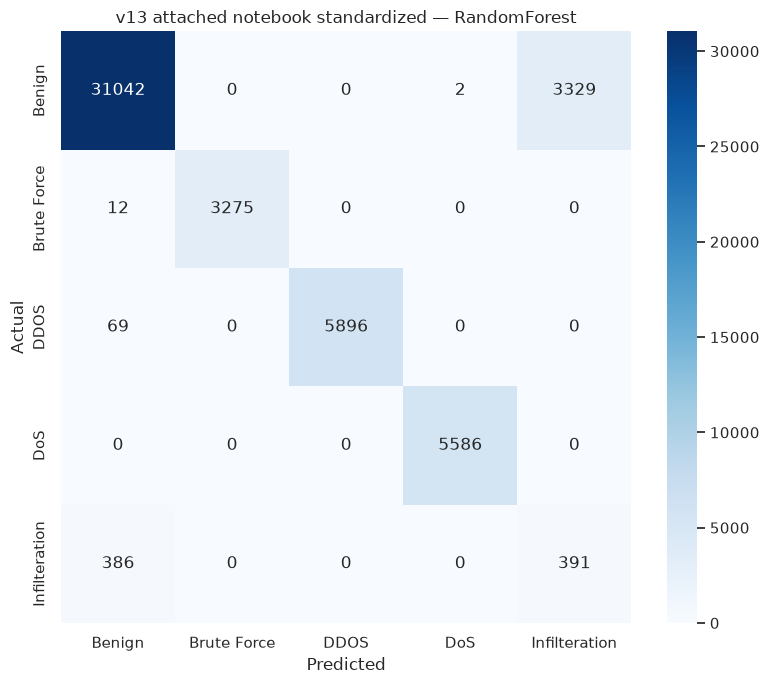

🏃 View run v13_candidate_RandomForest at: http://mlflow:5000/#/experiments/1/runs/e47096038e6947cebfe84b77973a4948
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v13_candidate_XGBoost at: http://mlflow:5000/#/experiments/1/runs/31d74d0c4514477d973837ae125675f6
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v13_candidate_LightGBM at: http://mlflow:5000/#/experiments/1/runs/e63f1f94801247eca41daca5fc8ab68a
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v13_candidate_Hierarchical_LightGBM at: http://mlflow:5000/#/experiments/1/runs/0d25fee7218342abbbfe2dc0f743136b
🧪 View experiment at: http://mlflow:5000/#/experiments/1


🏃 View run v13_attached_temporal_standardized_validation at: http://mlflow:5000/#/experiments/1/runs/6417f1ce20df4e90b5f15c44fe224c1a
🧪 View experiment at: http://mlflow:5000/#/experiments/1
Validation run: 6417f1ce20df4e90b5f15c44fe224c1a
Model URI: models:/m-56e9604329124fc08c8a9f54a1c6c05d
Status: /home/jovyan/work/network-classification/outputs/v13/BENCHMARK_ONLY.md


In [6]:
summary_path = OUTPUT_DIR / "v13_champion_summary.csv"
pd.DataFrame([{"model": "v13_attached_standardized", **metrics}]).to_csv(summary_path, index=False, encoding="utf-8-sig")
report_path = OUTPUT_DIR / "v13_classification_report.csv"
pd.DataFrame(classification_report(y_outer_valid, outer_prediction, labels=classes, output_dict=True, zero_division=0)).T.to_csv(report_path, encoding="utf-8-sig")
cm = confusion_matrix(y_outer_valid, outer_prediction, labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=classes, yticklabels=classes, ax=ax)
ax.set(title=f"v13 attached notebook standardized — {selected_name}", xlabel="Predicted", ylabel="Actual")
plt.tight_layout()
cm_path = OUTPUT_DIR / "v13_confusion_matrix.png"
fig.savefig(cm_path, dpi=140, bbox_inches="tight")
plt.show()

notebook_path = cwd / "code_mlflow_pipeline_v13.ipynb"
input_example = X_all.iloc[outer_valid_positions[:5]].copy()
signature = infer_signature(input_example, np.asarray(classes, dtype=object)[selected_model.predict(input_example)])
lineage_sample = sample_meta.iloc[:2000].copy()
lineage_numeric = lineage_sample.select_dtypes(include=[np.number]).columns
lineage_sample[lineage_numeric] = lineage_sample[lineage_numeric].astype(float)

with hypothesis_run(
    run_name="v13_attached_temporal_standardized_validation",
    hypothesis_id=HYPOTHESIS_ID, hypothesis=HYPOTHESIS,
    stage="chronological_validation", promotion_status="benchmark_only",
    validation_strategy="nested_time_selection_plus_class_chronological_80_20",
    notebook=notebook_path.name, data_version=RAW_TRAIN.name,
    feature_schema_version="attached-temporal-rolling-v1",
    code_version=file_sha256(notebook_path),
    extra_tags={
        "validation_cohort_id": VALIDATION_COHORT_ID,
        "strictly_comparable": "true",
        "source_attachment_sha256": SOURCE_ATTACHMENT_SHA256,
        "source_attachment_name": "code.ipynb",
        "serving_ready": "false",
        "registry_eligible": "false",
        "comparison_only_reason": "rolling_feature_service_not_implemented",
    },
) as parent_run:
    mlflow.log_params({
        "selected_model": selected_name,
        "candidate_count": len(candidate_models),
        "feature_count": X_all.shape[1],
        "flow_feature_count": len(selected_flow_features),
        "rolling_feature_count": X_all.shape[1] - len(selected_flow_features),
        "train_sample": TRAIN_SAMPLE,
        "random_state": RANDOM_STATE,
        "source_attachment_sha256": SOURCE_ATTACHMENT_SHA256,
        "training_data_sha256": file_sha256(RAW_TRAIN),
    })
    mlflow.log_metrics({**{key: float(value) for key, value in metrics.items()}, "train_seconds": train_seconds})
    log_dataframe_input(lineage_sample, source=RAW_TRAIN, name="raw_benchmark_cohort_sample", context="attached_notebook_standardized", targets=TARGET)
    for artifact in [candidate_path, summary_path, report_path, cm_path, feature_manifest_path]:
        mlflow.log_artifact(str(artifact))
    mlflow.log_artifact(str(notebook_path), artifact_path="code")
    for row in candidate_rows:
        with mlflow.start_run(run_name=f"v13_candidate_{row['candidate']}", nested=True):
            mlflow.set_tags({"hypothesis_id": HYPOTHESIS_ID, "stage": "inner_validation_candidate", "source_attachment": "code.ipynb"})
            mlflow.log_param("model", row["candidate"])
            mlflow.log_metrics({key: float(value) for key, value in row.items() if key != "candidate"})
    model_info = mlflow.sklearn.log_model(
        selected_model, name="benchmark_model",
        input_example=input_example, signature=signature,
        code_paths=[str(PROJECT_DIR / "src" / "attached_temporal_model.py")],
        metadata={"serving_ready": False, "requires_rolling_features": True},
    )
    validation_run_id = parent_run.info.run_id
    model_uri = model_info.model_uri

status_path = OUTPUT_DIR / "BENCHMARK_ONLY.md"
status_path.write_text(
    "# v13 status: benchmark only\n\n"
    f"- Source attachment SHA-256: `{SOURCE_ATTACHMENT_SHA256}`\n"
    f"- Selected model: {selected_name}\n"
    f"- Infilteration precision / recall / F1: {metrics['infilteration_precision']:.6f} / {metrics['infilteration_recall']:.6f} / {metrics['infilteration_f1']:.6f}\n"
    f"- Accuracy: {metrics['accuracy']:.6f}; false positives: {int(metrics['benign_to_infilteration_fp'])}\n"
    f"- Validation run: `{validation_run_id}`\n"
    f"- Model artifact: `{model_uri}`\n"
    "- Registry promotion disabled: online rolling feature service is not implemented.\n",
    encoding="utf-8",
)
print("Validation run:", validation_run_id)
print("Model URI:", model_uri)
print("Status:", status_path)
